2,4,12,14,21

In [1]:
from measurments import *
from generators import *
import numpy as np

# Задачи по варианту

## 2 задача. Заправки (0.5 балла)

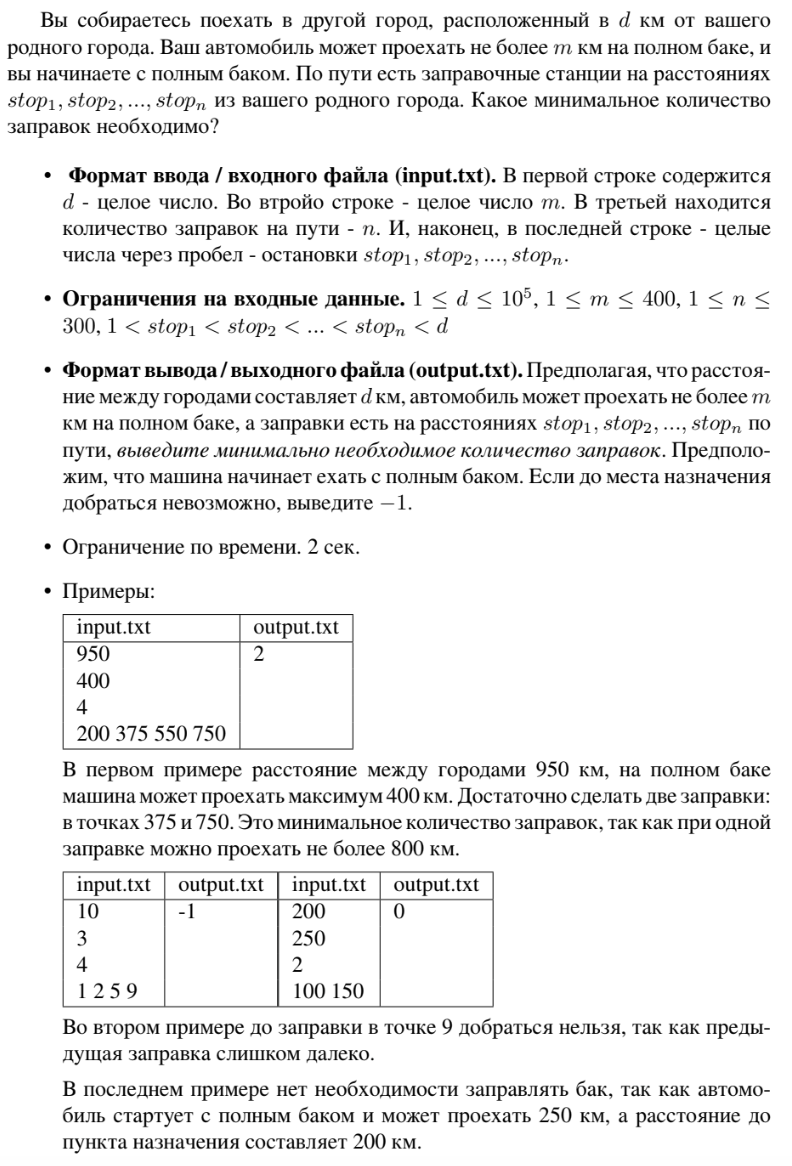

In [2]:
@measure_performance
def gas_stations(d, m, stations, n=0):
    if d <= m:
        return 0
    if d - stations[-1] > m:
        print(f'last gas station is {d - stations[-1]} away from destination, power reserve is {m}')
        return -1
    count = 0
    last_stop = 0
    for s in range(n):
        station = stations[s]
        prev_station = stations[s-1]
        if station - prev_station > m:
            print(f'distance between stations {s} and {s+1} is {station - prev_station}, power reserve is {m}')
            return -1
        if station - last_stop > m:
            count += 1
            last_stop = prev_station
    if d - last_stop > m:
        count += 1
    return count

### Результат работы кода на примерах из текста задачи:

#### ex1

In [3]:
gas_stations(950, 400, [200, 375, 550, 750], n=4)


--- Performance Report ---
Function: gas_stations(n=4)
Execution time: 0.000021 seconds
Peak memory: 0.00 MB
------------------------------


2

#### ex2

In [4]:
gas_stations(10, 3, [1, 2, 5, 9], n=4)

distance between stations 3 and 4 is 4, power reserve is 3

--- Performance Report ---
Function: gas_stations(n=4)
Execution time: 0.000078 seconds
Peak memory: 0.00 MB
------------------------------


-1

#### ex3

In [5]:
gas_stations(200, 250, [100, 150], n=2)


--- Performance Report ---
Function: gas_stations(n=2)
Execution time: 0.000006 seconds
Peak memory: 0.00 MB
------------------------------


0

#### ex4 (random)

In [6]:
dist, vol, num, arr = stations_generator()
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

60659 233 40 [    9   954  1419  1878  1948  2183  3283  3671  8202  8418 10398 12897
 15010 15462 16032 16039 17061 17561 18805 24500 24923 28344 34237 35165
 36913 37686 38252 38735 38888 39058 39669 40173 40287 43141 44251 48269
 50071 56130 57247 59208]
last gas station is 1451 away from destination, power reserve is 233

--- Performance Report ---
Function: gas_stations(n=40)
Execution time: 0.000037 seconds
Peak memory: 0.00 MB
------------------------------


-1

### Результат работы кода на максимальных и минимальных значениях:

#### ex5 (max)

In [7]:
dist, vol, num, arr = stations_generator(10**5, 400, 300)
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

100000 400 300 [  198   376  1603  1794  2027  3133  3630  4651  4919  7155  7164  7727
  8051  8689  9215  9381  9469  9911  9915 10508 11048 11387 11813 12060
 12302 12411 12599 12944 13460 13659 14121 14196 14951 15289 15317 15327
 15660 15807 16041 17151 17178 17398 17485 17711 18578 19328 19430 19798
 19854 20145 20358 20421 20519 21129 21285 22453 22905 23063 23234 23947
 24616 24690 25123 25166 25371 25531 26103 26812 26921 27077 27852 27875
 27898 27912 28483 28841 28860 29140 29285 29523 30139 30744 31539 31578
 31600 31852 32138 32415 32708 33454 33799 33808 33951 34172 34458 34515
 34636 34862 35388 35565 35575 35884 36810 36999 37144 37277 37281 37490
 37808 37939 38000 38682 39412 39972 40052 40128 40277 40707 41198 41343
 41548 41650 41652 41765 42138 42368 42460 42693 42834 43586 43800 43921
 44548 44690 44933 45028 45452 45876 45890 45904 46753 46807 46996 47625
 47783 47910 48071 48236 49502 49910 49945 52386 52824 53437 53537 54180
 54766 54804 54851 54871 55141 55182

-1

#### ex6 (min)

In [8]:
dist, vol, num, arr = stations_generator(1, 1, 1)
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

1 1 1 1

--- Performance Report ---
Function: gas_stations(n=1)
Execution time: 0.000006 seconds
Peak memory: 0.00 MB
------------------------------


0

## 4 задача. Сбор подписей (0.5 балла)

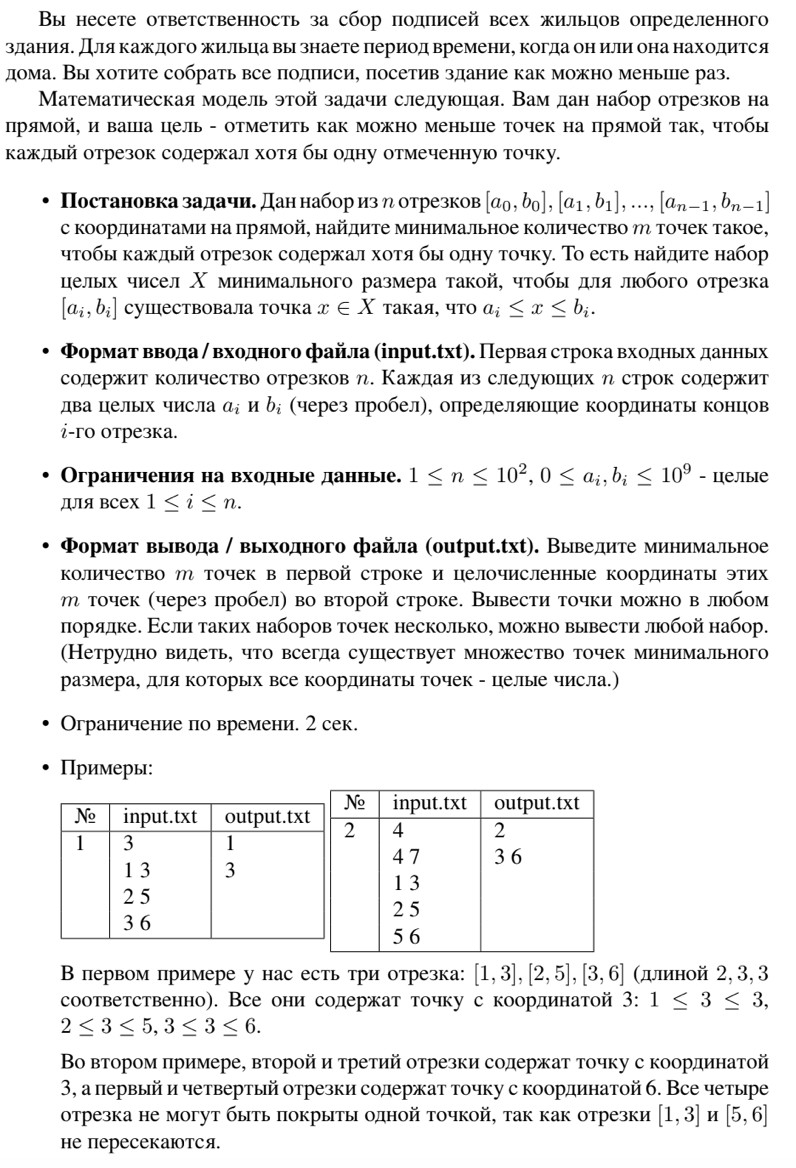

In [9]:
def partition3(A, l, r):
    x = A[l][1]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i][1] < x:
            A[lt], A[i] = A[i], A[lt]
            lt += 1
            i += 1
        elif A[i][1] > x:
            A[i], A[gt] = A[gt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3(A, l, r)
        randomized_quick_sort(A, l, m1 - 1)
        randomized_quick_sort(A, m2 + 1, r)
    return A

In [10]:
import random

@measure_performance
def segments_intersection(segments, n=0):
    if n == 1:
        return 1, random.randint(segments[0][0], segments[0][1])
    if n == 2:
        if segments[0][1] <= segments[1][0]:
            return 1, segments[0][1]
        elif segments[1][1] <= segments[0][0]:
            return 1, segments[1][1]
        else:
            return 2, segments[0][1], segments[1][0]
    else:
        sorted_segments = randomized_quick_sort(segments, 0, n-1)
        b_current = sorted_segments[0][1]
        count = 1
        dots = [b_current]
        for segm in sorted_segments[1:]:
            if b_current >= segm[0]:
                continue
            else:
                b_current = segm[1]
                dots.append(b_current)
                count += 1
        return count, dots

In [11]:
def is_valid(segments, points):
    for a, b in segments:
        # Проверяем, есть ли хотя бы одна точка из points в отрезке [a, b]
        if not any(a <= p <= b for p in points):
            return False, (a, b) # Вернет отрезок, который не покрыт
    return True, None

In [12]:
segments_intersection([(1, 3), (2, 5), (3, 6)], n=3)


--- Performance Report ---
Function: segments_intersection(n=3)
Execution time: 0.000019 seconds
Peak memory: 0.00 MB
------------------------------


(1, [3])

In [13]:
segments_intersection([(4, 7), (1, 3), (2, 5), (5, 6)], n=4)


--- Performance Report ---
Function: segments_intersection(n=4)
Execution time: 0.000023 seconds
Peak memory: 0.00 MB
------------------------------


(2, [3, 6])

In [14]:
num, arr = segments_generator(100)
print(num, arr)
min_num, min_arr = segments_intersection(arr, n=num)
valid, failed_segment = is_valid(arr, min_arr)
if valid:
    print("Алгоритм отработал верно: все отрезки покрыты!")
else:
    print(f"Ошибка! Отрезок {failed_segment} не покрыт.")
print(min_num, min_arr)

100 [(160600923, 432273534), (171208103, 214800689), (526390467, 935740998), (215077013, 283836266), (227500032, 629663919), (508851488, 752410184), (55748078, 627919912), (23666685, 97776060), (521680091, 549533296), (836735680, 904120907), (99637458, 986515145), (235327470, 909129279), (557412034, 746970040), (145390843, 934145236), (811123547, 939726520), (774557836, 873447220), (401376439, 854698929), (125205177, 976350816), (739823123, 943249434), (287802183, 497184047), (704089790, 979660213), (346101312, 839925143), (260541252, 547458423), (236138804, 995994102), (461048565, 589435159), (807772525, 955874590), (121743559, 737235055), (91004236, 951057152), (89419364, 833864818), (342690698, 344033583), (639881081, 915828685), (6100528, 781186493), (699038709, 777099790), (910543643, 938047777), (273451557, 464962306), (886313015, 990946396), (396567294, 601004565), (161256968, 542067400), (987070340, 998890432), (947445119, 978789686), (829714926, 872883652), (154371115, 5085576

## 12 задача. Последовательность (1 балл)

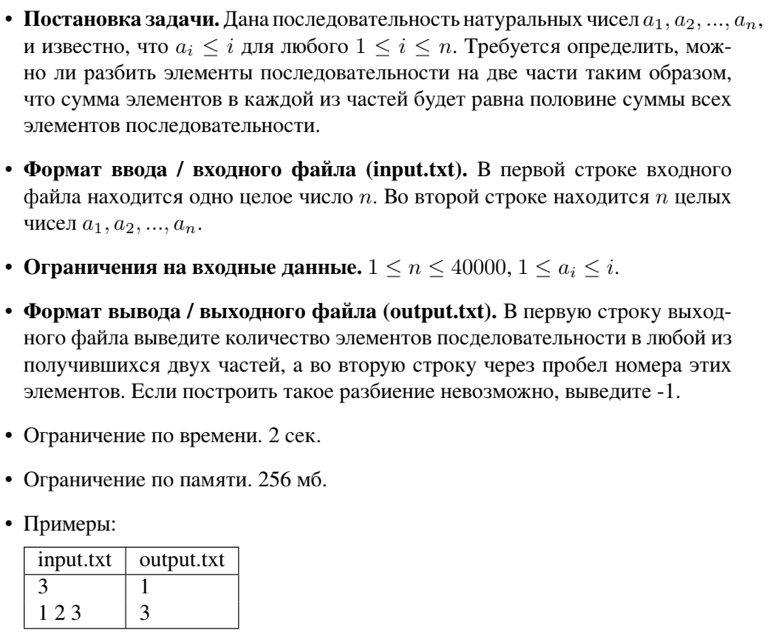

In [15]:
def partition3_inv(A, l, r):
    x = A[l][0]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i][0] < x:
            A[gt], A[i] = A[i], A[gt]
            lt += 1
            i += 1
        elif A[i][0] > x:
            A[i], A[lt] = A[lt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort_inv(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3_inv(A, l, r)
        randomized_quick_sort_inv(A, l, m1 - 1)
        randomized_quick_sort_inv(A, m2 + 1, r)
    return A

In [16]:
def partition3_norm(A, l, r):
    x = A[l]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i] < x:
            A[lt], A[i] = A[i], A[lt]
            lt += 1
            i += 1
        elif A[i] > x:
            A[i], A[gt] = A[gt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort_norm(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3_norm(A, l, r)
        randomized_quick_sort_norm(A, l, m1 - 1)
        randomized_quick_sort_norm(A, m2 + 1, r)
    return A

In [17]:
@measure_base_performance
def subsequence1(sequence, n=0):
    if n == 1:
        return -1

    elif n == 2:
        if sequence[0] != sequence[1]:
            return -1
        else:
            return 1, 1

    else:
        if sum(sequence) % 2 != 0:
            print('sum is not even')
            return -1
        else:

            target = sum(sequence) // 2
            current_mask = 1
            masks = [0] * n

            for i in range(n):
                masks[i] = current_mask
                current_mask |= (current_mask << sequence[i])

            if not (current_mask >> target) & 1:
                print('sum is unreachable')
                return -1

            inds_subseq = []
            curr_target = target

            for i in range(n - 1, -1, -1):

                if sequence[i] == curr_target:
                    inds_subseq.append(i + 1)
                    curr_target -= sequence[i]
                    return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)

                if not (masks[i] >> curr_target) & 1:
                    inds_subseq.append(i + 1)
                    curr_target -= sequence[i]

                if curr_target == 0: return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)

            return -1

In [18]:
@measure_base_performance
def subsequence(sequence, n=0):
    if n < 2: return -1

    total_sum = sum(sequence)
    if total_sum % 2 != 0:
        print('sum is not even')
        return -1

    target = total_sum // 2
    K = 100

    checkpoints = {}
    current_mask = 1

    for i in range(n):
        if i % K == 0:
            checkpoints[i] = current_mask
        current_mask |= (current_mask << sequence[i])

    # Проверка достижимости
    if not (current_mask >> target) & 1:
        print('sum is unreachable')
        return -1

    inds_subseq = []
    curr_target = target

    i = n - 1
    while i >= 0:
        cp_idx = (i // K) * K
        temp_mask = checkpoints[cp_idx]
        local_masks = []

        for j in range(cp_idx, i + 1):
            local_masks.append(temp_mask)
            temp_mask |= (temp_mask << sequence[j])

        for j in range(i, cp_idx - 1, -1):
            val = sequence[j]
            mask_before_val = local_masks[j - cp_idx]

            if val == curr_target:
                inds_subseq.append(j + 1)
                curr_target = 0
                break

            if curr_target >= val and not (mask_before_val >> curr_target) & 1:
                inds_subseq.append(j + 1)
                curr_target -= val

            if curr_target == 0: break

        if curr_target == 0: break
        i = cp_idx - 1

    if curr_target == 0:
        return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)
    return -1

In [19]:
subsequence([1, 2, 3], n=3)


--- Performance Report ---
Function: subsequence(n=3)
Execution time: 0.010124 seconds
Peak memory: 224.11 MB (229488.00 KB)
------------------------------


(1, [3])

In [20]:
num, arr = sequences_generator(4000)
print(num, arr)
subsequence(arr, n=num)

4000 [1, 2, 2, 4, 2, 1, 7, 2, 7, 1, 2, 1, 6, 8, 4, 7, 14, 12, 19, 1, 17, 6, 7, 14, 12, 9, 25, 6, 28, 14, 28, 1, 16, 11, 23, 5, 25, 6, 18, 34, 14, 11, 35, 37, 29, 37, 33, 12, 26, 26, 34, 27, 23, 38, 48, 55, 41, 27, 34, 30, 19, 44, 28, 15, 43, 52, 41, 40, 39, 16, 64, 38, 55, 17, 36, 36, 2, 10, 42, 18, 41, 35, 79, 24, 68, 66, 71, 84, 77, 15, 61, 43, 88, 4, 20, 42, 60, 75, 10, 19, 36, 33, 38, 70, 4, 39, 25, 20, 9, 97, 55, 31, 74, 58, 42, 59, 71, 61, 98, 25, 65, 19, 96, 83, 84, 18, 2, 108, 9, 35, 119, 106, 18, 131, 61, 72, 32, 67, 108, 130, 112, 117, 9, 21, 25, 132, 79, 48, 32, 121, 4, 39, 37, 32, 91, 93, 29, 136, 63, 143, 134, 84, 62, 106, 70, 148, 17, 123, 59, 82, 109, 144, 113, 27, 90, 114, 112, 132, 138, 50, 135, 106, 25, 149, 60, 43, 48, 139, 144, 6, 5, 168, 4, 29, 121, 68, 124, 132, 57, 47, 83, 70, 41, 127, 113, 79, 116, 12, 144, 171, 38, 114, 178, 157, 97, 143, 70, 5, 202, 77, 122, 184, 114, 168, 90, 141, 95, 163, 10, 27, 179, 65, 149, 40, 140, 159, 192, 213, 202, 208, 208, 88, 110, 

(2804,
 [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  

## 14 задача. Максимальное значение арифметического выражения (2 балла)

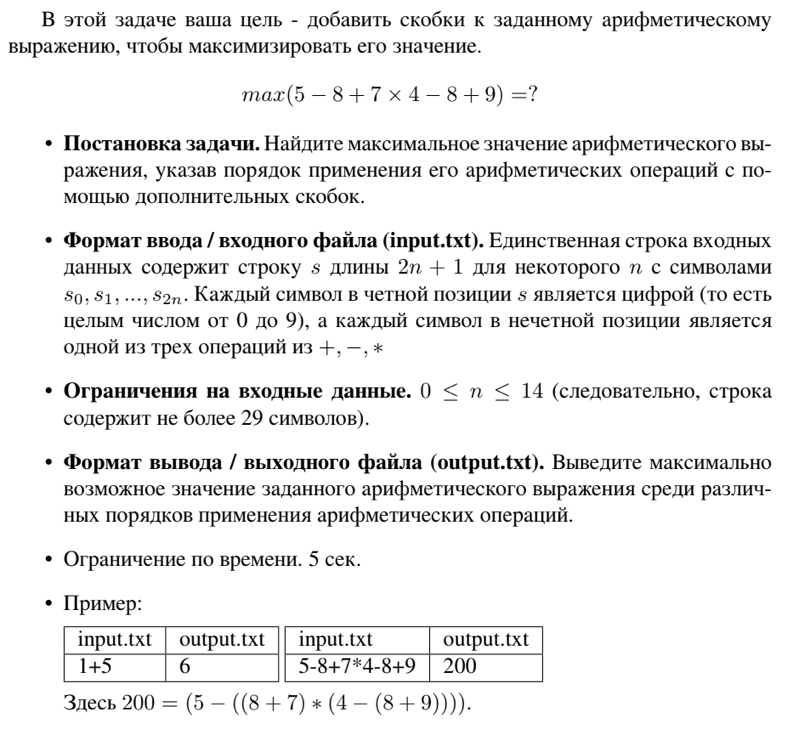

In [21]:
def arithmetics(d1, d2, op):
    if op == '+':
        return d1 + d2
    elif op == '-':
        return d1 - d2
    elif op == '*':
        return d1 * d2

def listed_seq(stroka):
    lstr = list(stroka)
    digits = [int(lstr[k]) for k in range(len(lstr)) if k % 2 == 0]
    operations = [lstr[k] for k in range(len(lstr)) if k % 2 == 1]
    return digits, operations

@measure_performance
def brackets_seq(stroka, n=None):
    digits, ops = listed_seq(stroka)
    if len(digits) == 2:
        return arithmetics(digits[0], digits[1], ops[0])
    elif len(digits) == 1:
        return digits[0]
    else:
        mins = [[0] * len(digits) for _ in range(len(digits))]
        maxs = [[0] * len(digits) for _ in range(len(digits))]
        for i in range(len(digits)):
            mins[i][i], maxs[i][i] = digits[i], digits[i]

        for l in range(2, len(digits) + 1):
            for i in range(len(digits) - l + 1):
                results = []
                j = i + l - 1
                for k in range(i, j):
                    results.append(arithmetics(maxs[i][k], maxs[k+1][j], ops[k]))
                    results.append(arithmetics(maxs[i][k], mins[k+1][j], ops[k]))
                    results.append(arithmetics(mins[i][k], maxs[k+1][j], ops[k]))
                    results.append(arithmetics(mins[i][k], mins[k+1][j], ops[k]))
                mins[i][j], maxs[i][j] = min(results), max(results)
        return maxs[0][-1]

In [22]:
ex1 = '1+5'
brackets_seq(ex1, n=len(ex1))


--- Performance Report ---
Function: brackets_seq(n=3)
Execution time: 0.000017 seconds
Peak memory: 0.00 MB
------------------------------


6

In [23]:
ex2 = '5-8+7*4-8+9'
brackets_seq(ex2, n=len(ex2))


--- Performance Report ---
Function: brackets_seq(n=11)
Execution time: 0.000143 seconds
Peak memory: 0.00 MB
------------------------------


200

In [24]:
expr, lngth = expression_generator(14)
print(f'original expression: {expr}')

brackets_seq(expr, n=lngth)

original expression: 6+7-4-1*1-4-3+0+0-5*0-8-1-8

--- Performance Report ---
Function: brackets_seq(n=29)
Execution time: 0.000816 seconds
Peak memory: 0.01 MB
------------------------------


1870

In [25]:
expr, lngth = expression_generator(13)
print(f'original expression: {expr}')

brackets_seq(expr, n=lngth)

original expression: 3*9-2+1-9-6*1+8*2+3+1*2*9

--- Performance Report ---
Function: brackets_seq(n=27)
Execution time: 0.000745 seconds
Peak memory: 0.01 MB
------------------------------


61236

## 21 задача. Игра в дурака (3 балла)

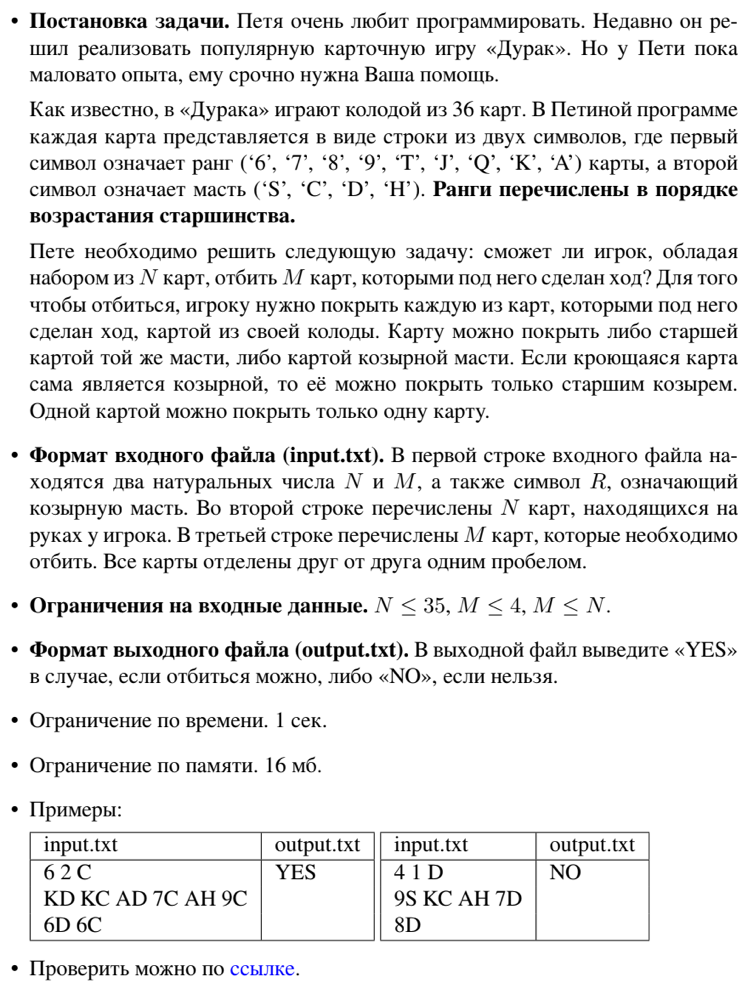

In [26]:
def cards_unpacking(cards_stroka):
    return [(card[0], card[1]) for card in cards_stroka.split()]

def can_beat(attacker, defender, trump, order):
    if attacker[1] == trump:
        if defender[1] != trump:
            return True
        else:
            return order[attacker[0]] > order[defender[0]]
    else:
        if defender[1] == trump:
            return False
        else:
            return (attacker[1] == defender[1] and
                   order[attacker[0]] > order[defender[0]])

def can_cover(i, m, n, rival_cards, player_cards, used, trump):
    order = {rang: i for i, rang in enumerate(['6','7','8','9','T','J','Q','K','A'])}
    if i == m:
        return True
    else:
        for j in range(n):
            if j not in used and can_beat(player_cards[j], rival_cards[i], trump, order):
                used.append(j)
                if can_cover(i + 1, m, n, rival_cards, player_cards, used, trump):
                    return True
                used.pop()
        return False


@measure_plural_performance
def durak(trump, player_cards, rival_cards, n=None, m=None):
    player_cards = cards_unpacking(player_cards)
    rival_cards = cards_unpacking(rival_cards)
    if m == 1 and rival_cards[0][0] == 'A' and rival_cards[0][1] == trump:
        return 'NO'
    else:
        used = []
        return 'YES' if can_cover(0, m, n, rival_cards, player_cards, used, trump) else 'NO'

In [27]:
durak('C', 'KD KC AD 7C AH 9C', '6D 6C', n=6, m=2)


--- Performance Report ---
Function: durak(n=6, m=2)
Execution time: 0.000029 seconds
Peak memory: 0.00 MB
------------------------------


'YES'

In [28]:
durak('D', '9S KC AH 7D', '8D', n=4, m=1)


--- Performance Report ---
Function: durak(n=4, m=1)
Execution time: 0.000020 seconds
Peak memory: 0.00 MB
------------------------------


'NO'

In [29]:
pl_n, pl, tbl_m, tbl, trmp = cards_generator()

print(f'player cards: {pl_n}, {pl}, table cads: {tbl_m}, {tbl}')

durak(trmp, pl, tbl, n=pl_n, m=tbl_m)

player cards: 29, QD 8S 6D 7D QS KH 7H QC JH JD 6C KD 9C QH 9S AS TH 9H AC AD 6H JS AH 9D TD KC 8C 6S TC, table cads: 2, 7C 8H

--- Performance Report ---
Function: durak(n=29, m=2)
Execution time: 0.000047 seconds
Peak memory: 0.00 MB
------------------------------


'YES'